# 💊 Drugs, Side Effects and Medical Condition
## Exploratory Data Analysis & Machine Learning Project

**Domain:** Data Analytics & Data Science  
**Difficulty Level:** Intermediate  
**Tools:** Python, Pandas, Matplotlib, Seaborn, Scikit-learn, mlxtend  
**Dataset Source:** drugs.com

---

### 📌 Project Objective
Analyze the relationships between drugs, their side effects, and the medical conditions they treat.  
Explore ratings, reviews, drug classifications, and pregnancy safety categories through visualizations and ML techniques.

---

## 📦 Section 1: Import Libraries

In [2]:
# Core Libraries
import pandas as pd
import numpy as np
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score)
from sklearn.cluster import KMeans

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📂 Section 2: Load Dataset

In [5]:
# Load the dataset — update path if needed
fpath = 'drugs.csv'
data = pd.read_csv(fpath)

print(f'📊 Dataset Shape: {data.shape[0]} rows × {data.shape[1]} columns')
print(f'\n📋 Columns ({len(data.columns)}):')
for i, col in enumerate(data.columns, 1):
    print(f'  {i:2}. {col}')

📊 Dataset Shape: 2931 rows × 17 columns

📋 Columns (17):
   1. drug_name
   2. medical_condition
   3. side_effects
   4. generic_name
   5. drug_classes
   6. brand_names
   7. activity
   8. rx_otc
   9. pregnancy_category
  10. csa
  11. alcohol
  12. related_drugs
  13. medical_condition_description
  14. rating
  15. no_of_reviews
  16. drug_link
  17. medical_condition_url


In [6]:
# Preview first 5 rows
data.head()

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews,drug_link,medical_condition_url
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,N,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0,https://www.drugs.com/doxycycline.html,https://www.drugs.com/condition/acne.html
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,N,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0,https://www.drugs.com/spironolactone.html,https://www.drugs.com/condition/acne.html
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,N,NaN,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0,https://www.drugs.com/minocycline.html,https://www.drugs.com/condition/acne.html
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,41%,Rx,X,N,X,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0,https://www.drugs.com/accutane.html,https://www.drugs.com/condition/acne.html
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,N,NaN,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0,https://www.drugs.com/mtm/clindamycin-topical....,https://www.drugs.com/condition/acne.html


In [7]:
# Dataset info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2931 entries, 0 to 2930
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   drug_name                      2931 non-null   object 
 1   medical_condition              2931 non-null   object 
 2   side_effects                   2807 non-null   object 
 3   generic_name                   2888 non-null   object 
 4   drug_classes                   2849 non-null   object 
 5   brand_names                    1718 non-null   object 
 6   activity                       2931 non-null   object 
 7   rx_otc                         2930 non-null   object 
 8   pregnancy_category             2702 non-null   object 
 9   csa                            2931 non-null   object 
 10  alcohol                        1377 non-null   object 
 11  related_drugs                  1462 non-null   object 
 12  medical_condition_description  2931 non-null   o

---
## 🧹 Section 3: Data Cleaning & Preprocessing

In [8]:
# Step 3.1 — Check missing values
print('=== Missing Values Before Cleaning ===')
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df)
print(f'\nTotal missing values: {data.isnull().sum().sum()}')

=== Missing Values Before Cleaning ===
                    Missing Count  Missing %
alcohol                      1554      53.02
related_drugs                1469      50.12
rating                       1345      45.89
no_of_reviews                1345      45.89
brand_names                  1213      41.39
pregnancy_category            229       7.81
side_effects                  124       4.23
drug_classes                   82       2.80
generic_name                   43       1.47
rx_otc                          1       0.03

Total missing values: 7405


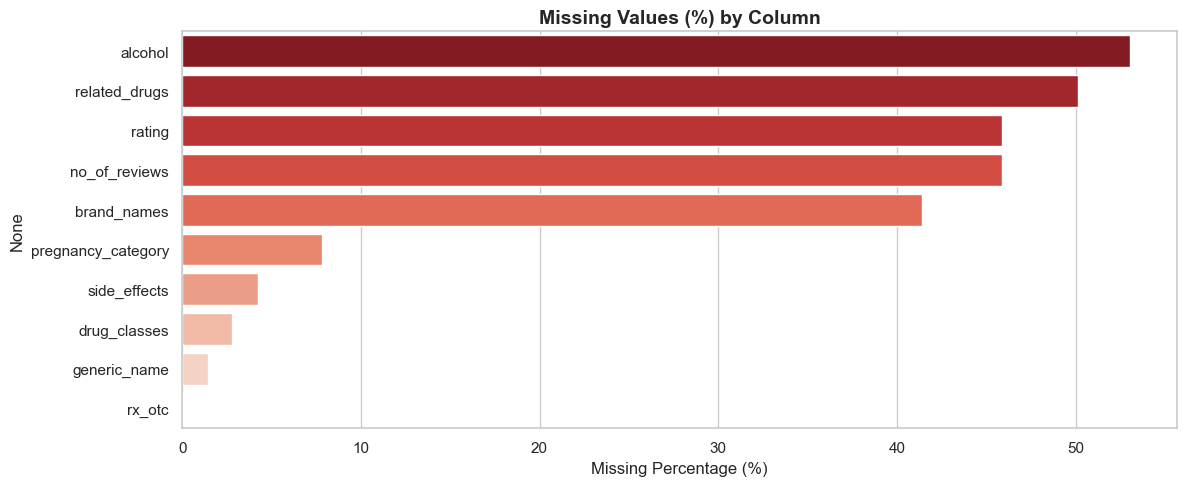

In [9]:
# Visualize missing values
plt.figure(figsize=(12, 5))
missing_plot = missing_df['Missing %']
sns.barplot(x=missing_plot.values, y=missing_plot.index, palette='Reds_r')
plt.title('Missing Values (%) by Column', fontsize=14, fontweight='bold')
plt.xlabel('Missing Percentage (%)')
plt.tight_layout()
plt.show()

In [10]:
# Step 3.2 — Check and remove duplicates
dup_count = data.duplicated().sum()
print(f'Duplicate rows found: {dup_count}')
data.drop_duplicates(inplace=True)
print(f'Dataset shape after removing duplicates: {data.shape}')

Duplicate rows found: 0
Dataset shape after removing duplicates: (2931, 17)


In [11]:
# Step 3.3 — Drop brand_names (>41% missing, not needed for analysis)
data.drop(columns=['brand_names'], inplace=True)
print('✅ Dropped brand_names column.')

✅ Dropped brand_names column.


In [12]:
# Step 3.4 — Fix data types

# Convert rating and no_of_reviews to numeric
data['rating'] = pd.to_numeric(data['rating'], errors='coerce')
data['no_of_reviews'] = pd.to_numeric(data['no_of_reviews'], errors='coerce')

# Clean 'activity' column: remove whitespace and '%', convert to float (0-1)
data['activity'] = (
    data['activity']
    .astype(str)
    .str.replace(r'\s+', '', regex=True)
    .str.rstrip('%')
    .astype('float') / 100
)

print('Data types after conversion:')
print(data[['rating', 'no_of_reviews', 'activity']].dtypes)

Data types after conversion:
rating           float64
no_of_reviews    float64
activity         float64
dtype: object


In [13]:
# Step 3.5 — Fill missing values intelligently

# Alcohol: X = interacts with alcohol (1), NaN = no interaction (0)
data['alcohol'] = data['alcohol'].fillna('0').replace({'X': 1, '0': 0}).astype(int)

# Text columns
data['side_effects']  = data['side_effects'].fillna('Unknown')
data['related_drugs'] = data['related_drugs'].fillna('Unknown')
data['generic_name']  = data['generic_name'].fillna('Unknown')
data['drug_classes']  = data['drug_classes'].fillna('Unknown')

# Categorical columns
data['rx_otc']              = data['rx_otc'].fillna('Unknown')
data['pregnancy_category']  = data['pregnancy_category'].fillna('Unknown')

# Numeric columns — fill with 0 (no data available)
data['rating']         = data['rating'].fillna(0)
data['no_of_reviews']  = data['no_of_reviews'].fillna(0)

print(f'Missing values after cleaning: {data.isnull().sum().sum()}')
print(f'Final dataset shape: {data.shape}')

Missing values after cleaning: 0
Final dataset shape: (2931, 16)


In [14]:
# Step 3.6 — Summary statistics
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
drug_name,2931,2912,triamcinolone,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
medical_condition,2931,47,Pain,264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
side_effects,2931,2760,Unknown,124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
generic_name,2931,1393,Unknown,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drug_classes,2931,275,Upper respiratory combinations,245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
activity,2931.0,NaN,NaN,NaN,0.084504,0.169333,0.0,0.0,0.02,0.07,1.0
rx_otc,2931,4,Rx,1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pregnancy_category,2931,7,C,1382,NaN,NaN,NaN,NaN,NaN,NaN,NaN
csa,2931,7,N,2688,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alcohol,2931.0,NaN,NaN,NaN,0.469806,0.499173,0.0,0.0,0.0,1.0,1.0


---
## 📊 Section 4: Exploratory Data Analysis (EDA)

### 4.1 Medical Condition Distribution

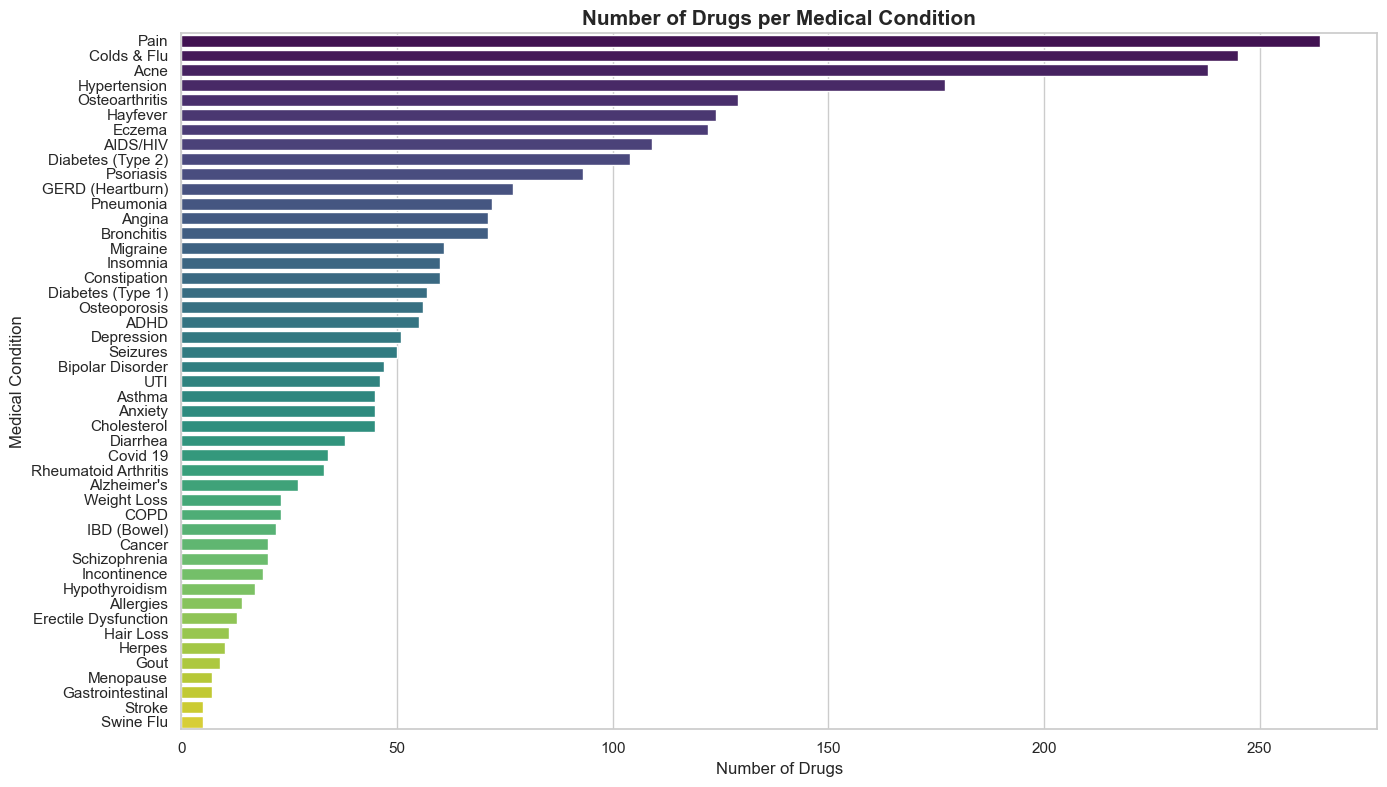


Total unique medical conditions: 47


In [15]:
condition_counts = data['medical_condition'].value_counts()

plt.figure(figsize=(14, 8))
sns.barplot(x=condition_counts.values, y=condition_counts.index, palette='viridis')
plt.title('Number of Drugs per Medical Condition', fontsize=15, fontweight='bold')
plt.xlabel('Number of Drugs')
plt.ylabel('Medical Condition')
plt.tight_layout()
plt.show()

print(f'\nTotal unique medical conditions: {data["medical_condition"].nunique()}')

### 4.2 Drug Rating Distribution

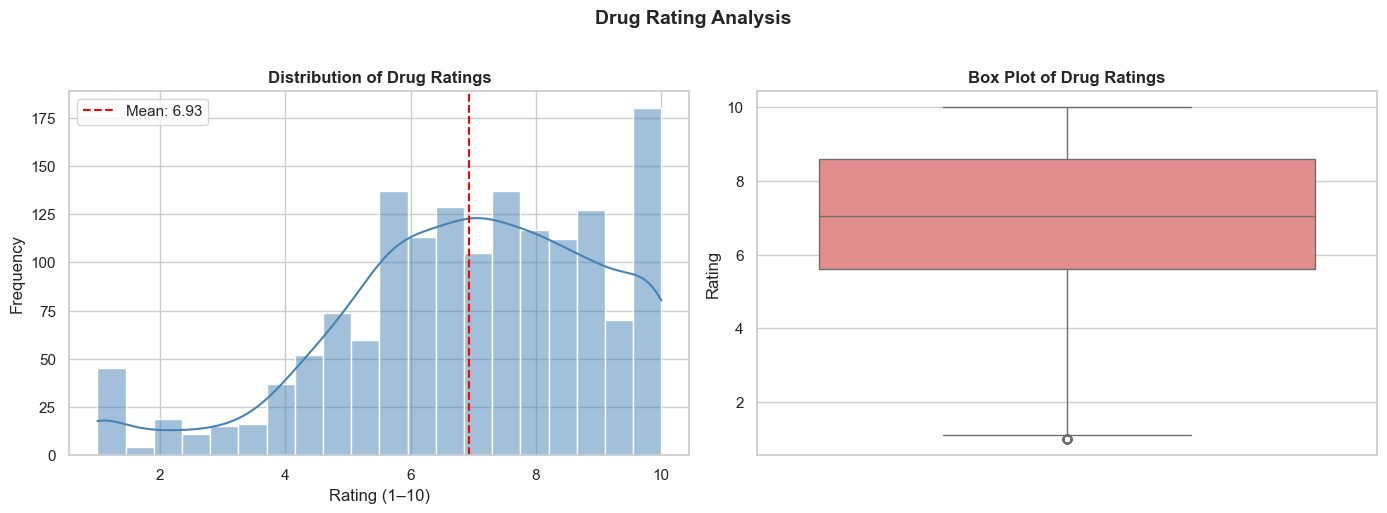

Mean Rating   : 6.93
Median Rating : 7.05
Std Dev       : 2.16


In [16]:
rated = data[data['rating'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(rated['rating'], bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Drug Ratings', fontweight='bold')
axes[0].set_xlabel('Rating (1–10)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(rated['rating'].mean(), color='red', linestyle='--', label=f'Mean: {rated["rating"].mean():.2f}')
axes[0].legend()

# Box plot
sns.boxplot(y=rated['rating'], ax=axes[1], color='lightcoral')
axes[1].set_title('Box Plot of Drug Ratings', fontweight='bold')
axes[1].set_ylabel('Rating')

plt.suptitle('Drug Rating Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Mean Rating   : {rated["rating"].mean():.2f}')
print(f'Median Rating : {rated["rating"].median():.2f}')
print(f'Std Dev       : {rated["rating"].std():.2f}')

### 4.3 Average Drug Rating by Medical Condition

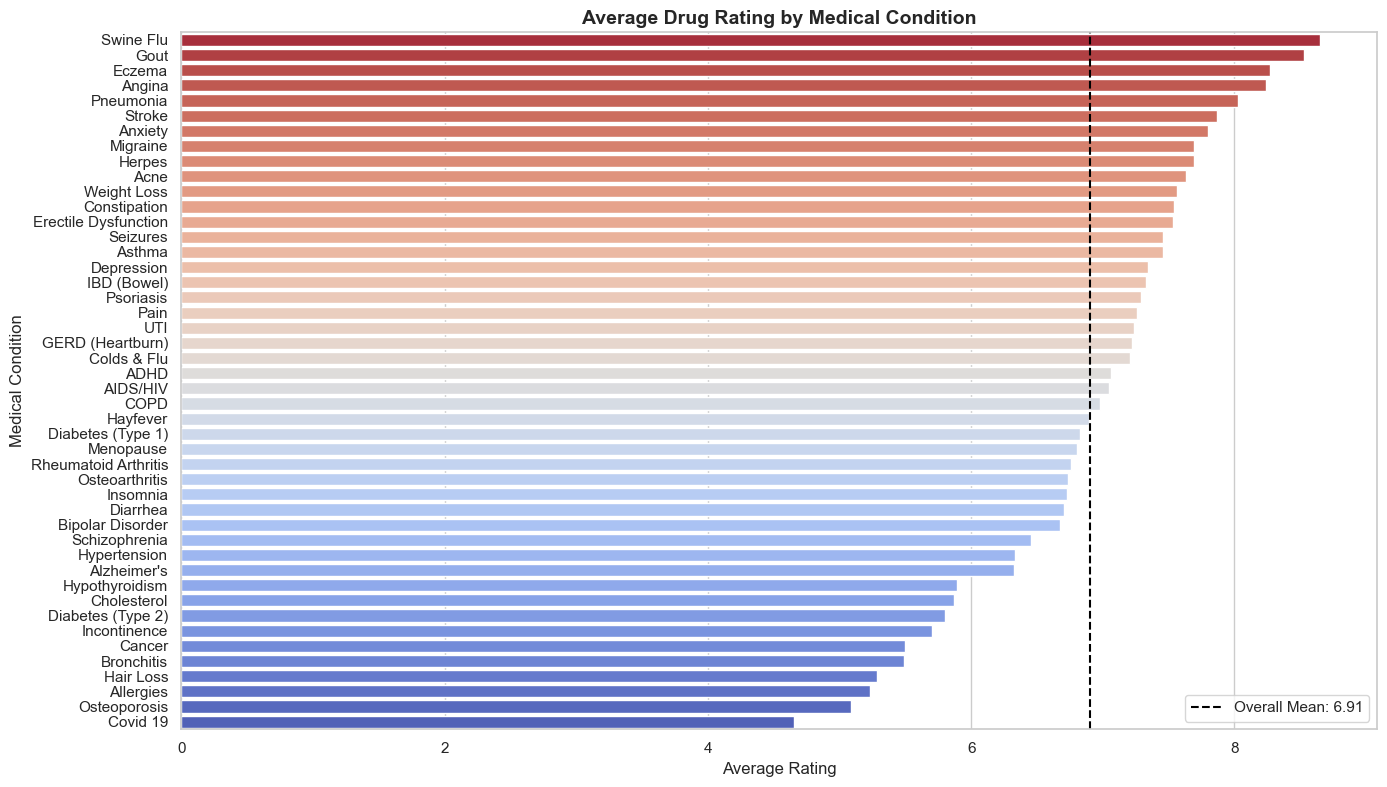

In [17]:
avg_rating = (
    data[data['rating'] > 0]
    .groupby('medical_condition')['rating']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(14, 8))
bars = sns.barplot(
    data=avg_rating, x='rating', y='medical_condition',
    palette='coolwarm_r'
)
plt.axvline(avg_rating['rating'].mean(), color='black', linestyle='--',
            label=f'Overall Mean: {avg_rating["rating"].mean():.2f}')
plt.title('Average Drug Rating by Medical Condition', fontsize=14, fontweight='bold')
plt.xlabel('Average Rating')
plt.ylabel('Medical Condition')
plt.legend()
plt.tight_layout()
plt.show()

### 4.4 Top 10 Most Common Side Effects

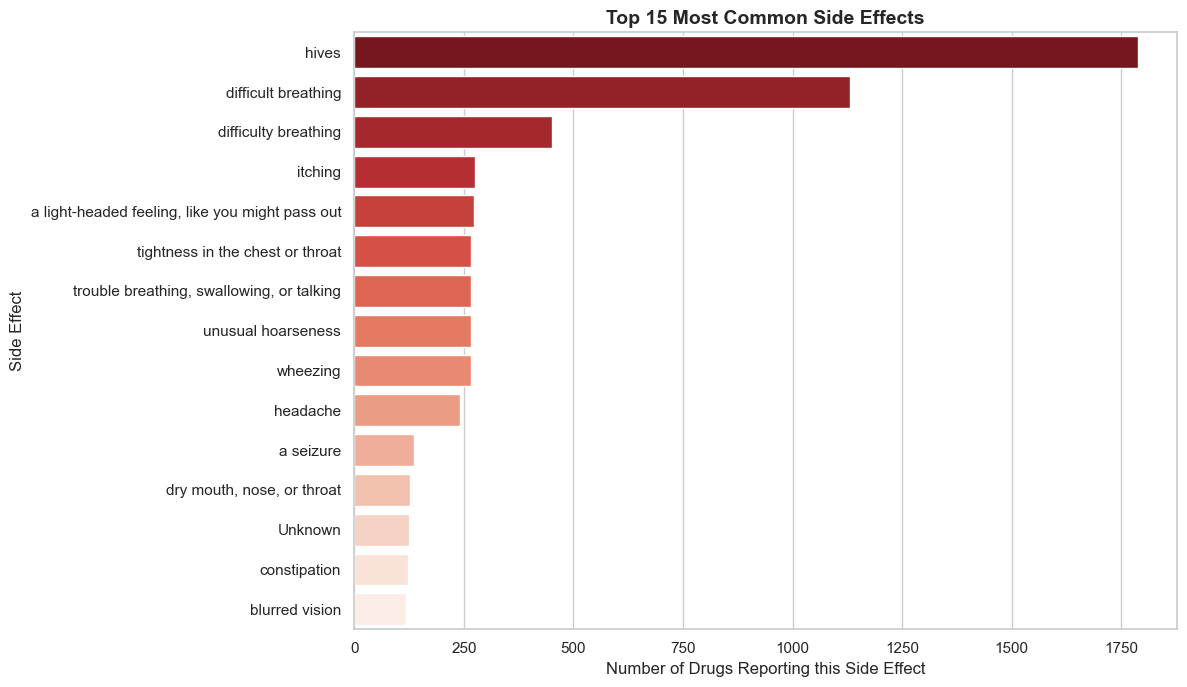

In [18]:
def extract_side_effects(text):
    return [e.strip() for e in re.split(r'[;]', str(text)) if e.strip()]

all_effects = (
    data['side_effects']
    .dropna()
    .apply(extract_side_effects)
    .explode()
)

# Filter meaningful entries (length < 60 chars)
all_effects = all_effects[all_effects.str.len() < 60]
top_effects = all_effects.value_counts().head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_effects.values, y=top_effects.index, palette='Reds_r')
plt.title('Top 15 Most Common Side Effects', fontsize=14, fontweight='bold')
plt.xlabel('Number of Drugs Reporting this Side Effect')
plt.ylabel('Side Effect')
plt.tight_layout()
plt.show()

### 4.5 Rx vs OTC Distribution

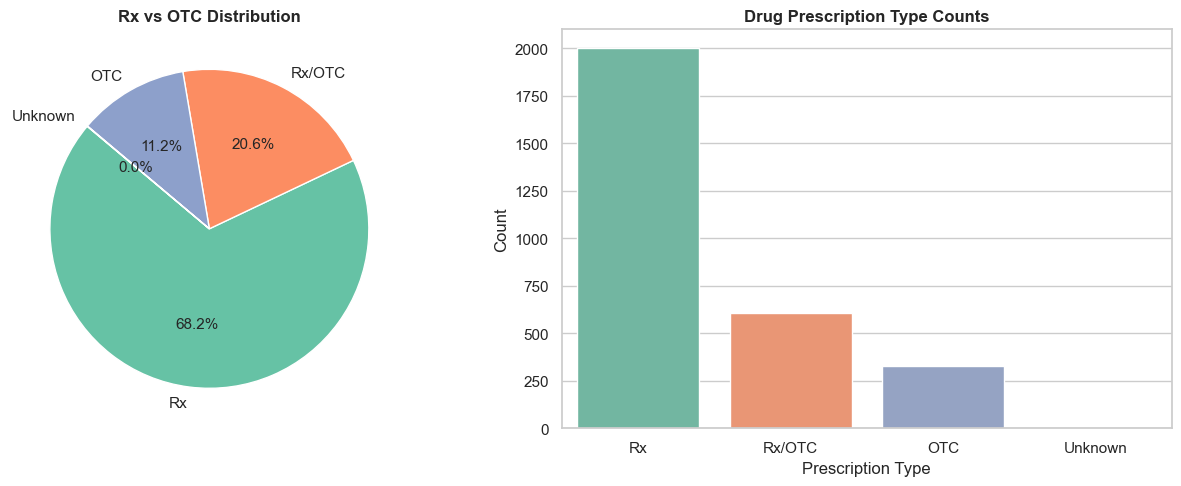

In [19]:
rx_counts = data['rx_otc'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
axes[0].pie(rx_counts.values, labels=rx_counts.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('Set2'))
axes[0].set_title('Rx vs OTC Distribution', fontweight='bold')

# Bar chart
sns.barplot(x=rx_counts.index, y=rx_counts.values, palette='Set2', ax=axes[1])
axes[1].set_title('Drug Prescription Type Counts', fontweight='bold')
axes[1].set_xlabel('Prescription Type')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 4.6 Pregnancy Category Distribution

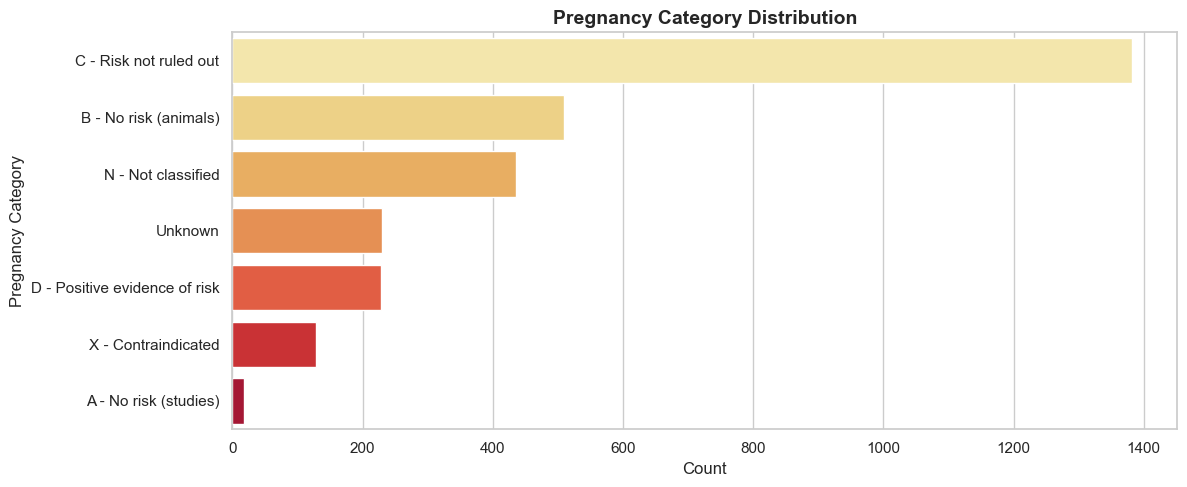

In [20]:
preg_counts = data['pregnancy_category'].value_counts()

# Category descriptions
preg_desc = {
    'A': 'A - No risk (studies)',
    'B': 'B - No risk (animals)',
    'C': 'C - Risk not ruled out',
    'D': 'D - Positive evidence of risk',
    'X': 'X - Contraindicated',
    'N': 'N - Not classified',
    'Unknown': 'Unknown'
}

labels = [preg_desc.get(k, k) for k in preg_counts.index]

plt.figure(figsize=(12, 5))
sns.barplot(x=preg_counts.values, y=labels, palette='YlOrRd')
plt.title('Pregnancy Category Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Pregnancy Category')
plt.tight_layout()
plt.show()

### 4.7 Top Drug Classes

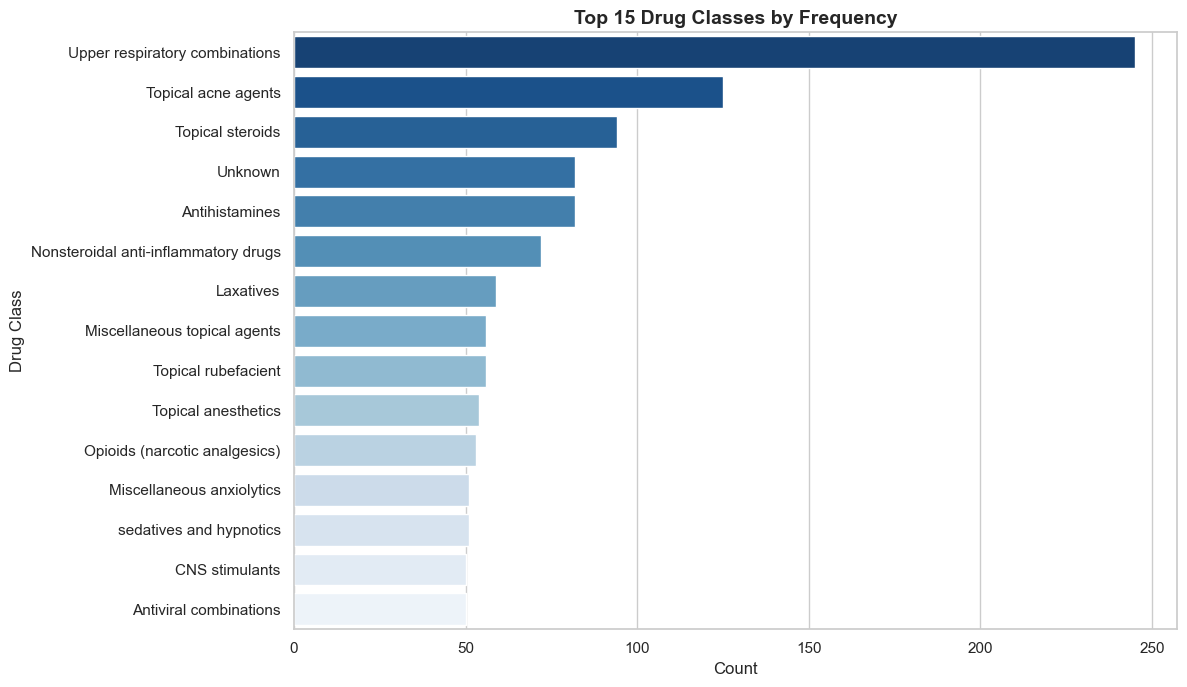

In [21]:
def extract_drug_classes(text):
    return [c.strip() for c in re.split(r'[,]', str(text)) if c.strip()]

all_classes = (
    data['drug_classes']
    .dropna()
    .apply(extract_drug_classes)
    .explode()
)
top_classes = all_classes.value_counts().head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_classes.values, y=top_classes.index, palette='Blues_r')
plt.title('Top 15 Drug Classes by Frequency', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Drug Class')
plt.tight_layout()
plt.show()

### 4.8 Activity vs Rating Scatter Plot

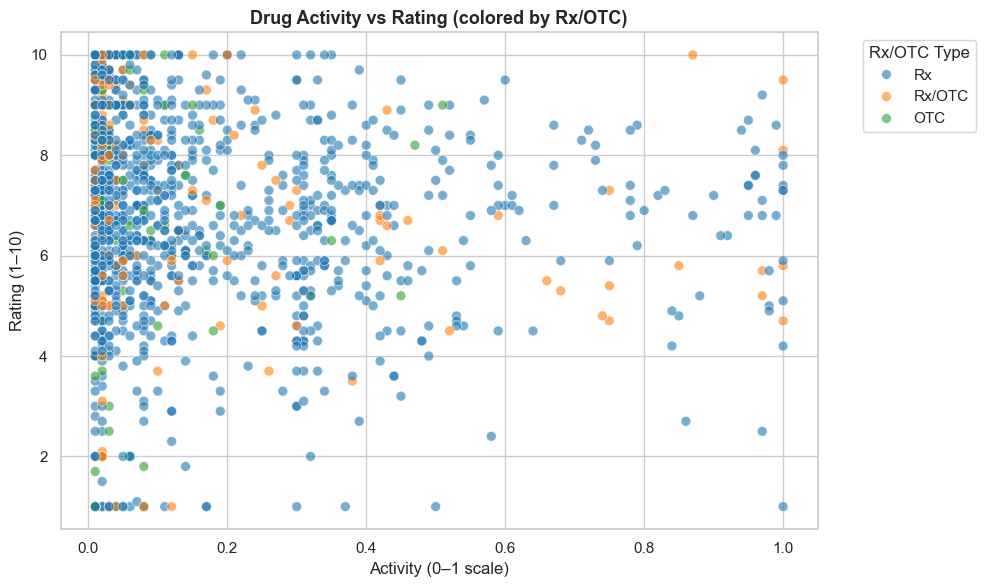

In [22]:
plot_df = data[(data['rating'] > 0) & (data['activity'] > 0)].copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df, x='activity', y='rating',
    hue='rx_otc', alpha=0.6, palette='tab10', s=50
)
plt.title('Drug Activity vs Rating (colored by Rx/OTC)', fontsize=13, fontweight='bold')
plt.xlabel('Activity (0–1 scale)')
plt.ylabel('Rating (1–10)')
plt.legend(title='Rx/OTC Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4.9 Number of Reviews vs Rating

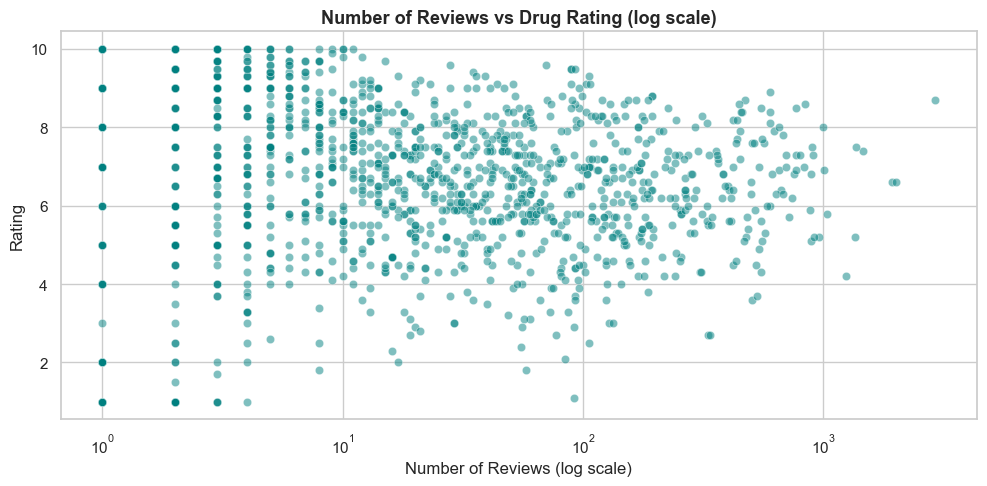

In [23]:
rev_df = data[(data['rating'] > 0) & (data['no_of_reviews'] > 0)].copy()

plt.figure(figsize=(10, 5))
sns.scatterplot(data=rev_df, x='no_of_reviews', y='rating', alpha=0.5, color='teal')
plt.xscale('log')
plt.title('Number of Reviews vs Drug Rating (log scale)', fontsize=13, fontweight='bold')
plt.xlabel('Number of Reviews (log scale)')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

### 4.10 Alcohol Interaction Analysis

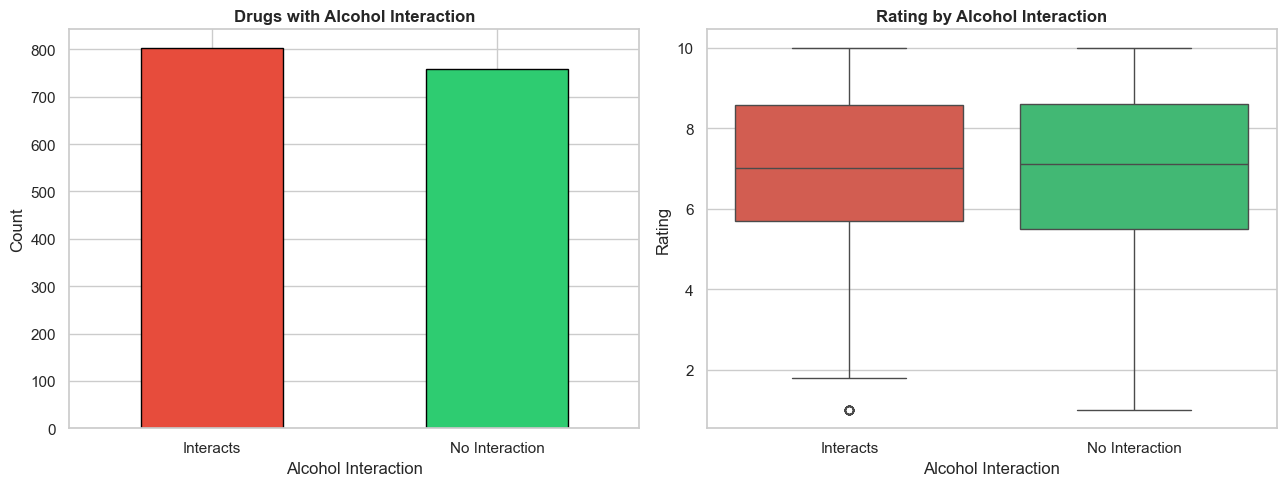

In [24]:
alc_rating = data[data['rating'] > 0].copy()
alc_rating['Alcohol Interaction'] = alc_rating['alcohol'].map({1: 'Interacts', 0: 'No Interaction'})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Count
alc_rating['Alcohol Interaction'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Drugs with Alcohol Interaction', fontweight='bold')
axes[0].set_xlabel('Alcohol Interaction')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Rating comparison
sns.boxplot(data=alc_rating, x='Alcohol Interaction', y='rating',
            palette={'Interacts': '#e74c3c', 'No Interaction': '#2ecc71'}, ax=axes[1])
axes[1].set_title('Rating by Alcohol Interaction', fontweight='bold')
axes[1].set_ylabel('Rating')

plt.tight_layout()
plt.show()

---
## 🔍 Section 5: Feature Engineering & Encoding

In [25]:
# Create a copy for ML
df_ml = data.copy()

# Create boolean side effect features
df_ml['has_hives']              = df_ml['side_effects'].str.lower().str.contains('hives').astype(int)
df_ml['has_difficult_breathing']= df_ml['side_effects'].str.lower().str.contains('difficult breathing|difficulty breathing').astype(int)
df_ml['has_itching']            = df_ml['side_effects'].str.lower().str.contains('itching').astype(int)
df_ml['has_nausea']             = df_ml['side_effects'].str.lower().str.contains('nausea').astype(int)
df_ml['has_dizziness']          = df_ml['side_effects'].str.lower().str.contains('dizziness').astype(int)

# Create target: high-rated drug (rating >= 7)
df_ml['high_rating'] = (df_ml['rating'] >= 7).astype(int)

# Encode categoricals
le = LabelEncoder()
for col in ['medical_condition', 'rx_otc', 'pregnancy_category', 'csa', 'generic_name', 'side_effects']:
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col].astype(str))

print('✅ Feature engineering complete!')
df_ml[['drug_name', 'has_hives', 'has_nausea', 'has_dizziness', 'high_rating']].head()

✅ Feature engineering complete!


,drug_name,has_hives,has_nausea,has_dizziness,high_rating
0,doxycycline,1,1,1,0
1,spironolactone,1,1,0,1
2,minocycline,0,1,1,0
3,Accutane,0,1,1,1
4,clindamycin,1,0,0,1


---
## 🔥 Section 6: Correlation Heatmap

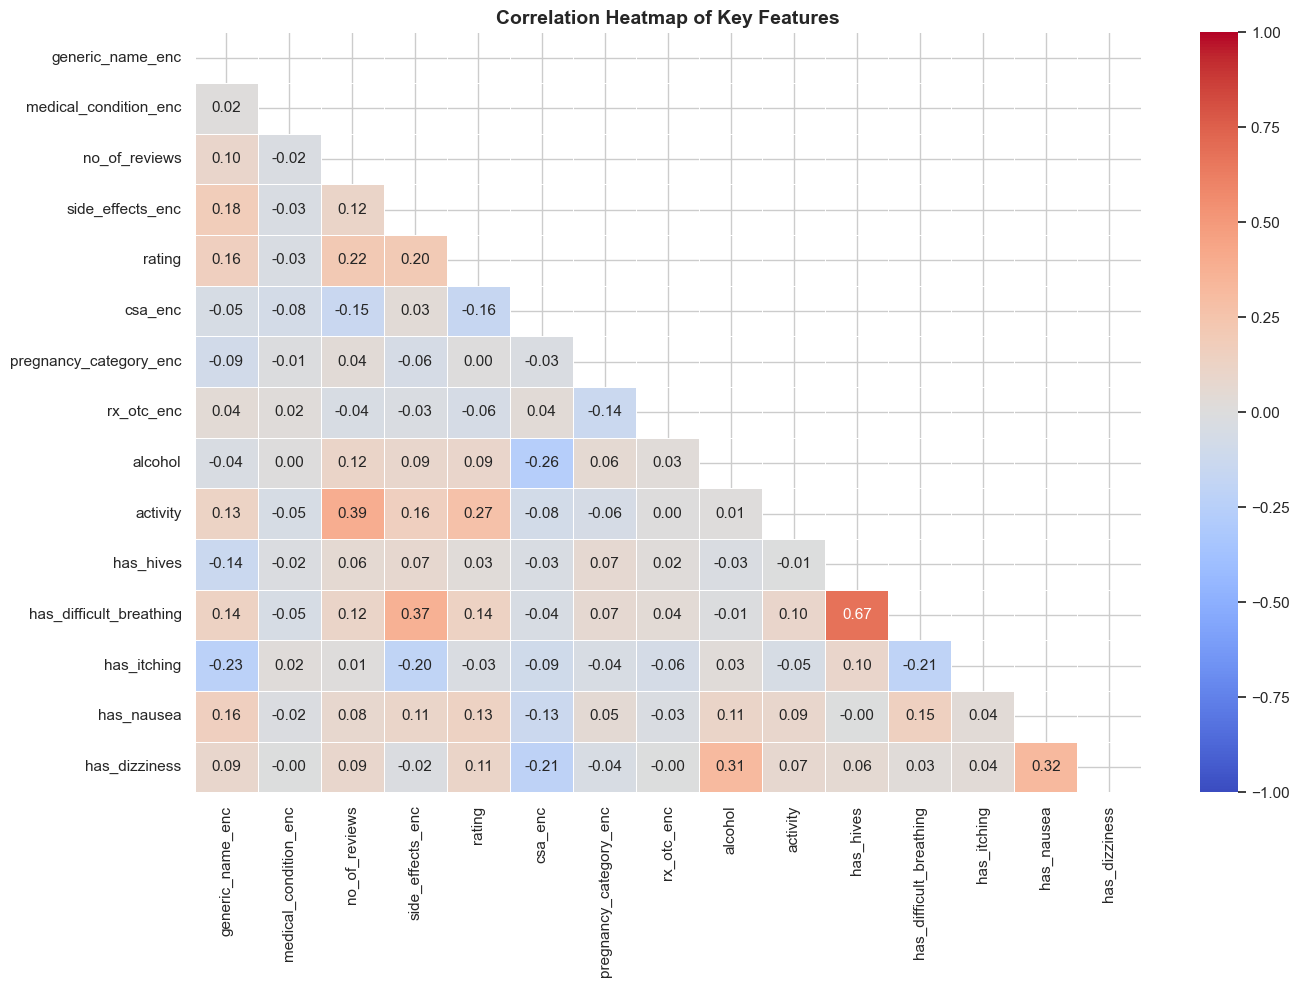

In [26]:
# Select numeric features for correlation
corr_cols = [
    'generic_name_enc', 'medical_condition_enc', 'no_of_reviews',
    'side_effects_enc', 'rating', 'csa_enc', 'pregnancy_category_enc',
    'rx_otc_enc', 'alcohol', 'activity',
    'has_hives', 'has_difficult_breathing', 'has_itching', 'has_nausea', 'has_dizziness'
]

corr_df = df_ml[corr_cols].copy()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(
    corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f',
    mask=mask, vmin=-1, vmax=1, linewidths=0.5
)
plt.title('Correlation Heatmap of Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🤖 Section 7: Machine Learning — Drug Rating Prediction

**Goal:** Predict whether a drug has a high rating (≥7) using classification models.

In [27]:
# Prepare features and target
feature_cols = [
    'generic_name_enc', 'medical_condition_enc', 'no_of_reviews',
    'csa_enc', 'pregnancy_category_enc', 'rx_otc_enc',
    'alcohol', 'activity',
    'has_hives', 'has_difficult_breathing', 'has_itching',
    'has_nausea', 'has_dizziness'
]

# Only use rows where rating is available (not filled with 0)
ml_data = df_ml[df_ml['rating'] > 0].copy()

X = ml_data[feature_cols]
y = ml_data['high_rating']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')
print(f'Class distribution (high_rating):\n{y.value_counts()}')

Training samples : 1248
Testing samples  : 312
Class distribution (high_rating):
high_rating
1    824
0    736
Name: count, dtype: int64


In [28]:
# Train and evaluate multiple models
models = {
    'Logistic Regression'     : LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree'           : DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest'           : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'       : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'{name:<28} Accuracy: {acc:.4f}')

Logistic Regression          Accuracy: 0.5897
Decision Tree                Accuracy: 0.6795
Random Forest                Accuracy: 0.7147
Gradient Boosting            Accuracy: 0.6731


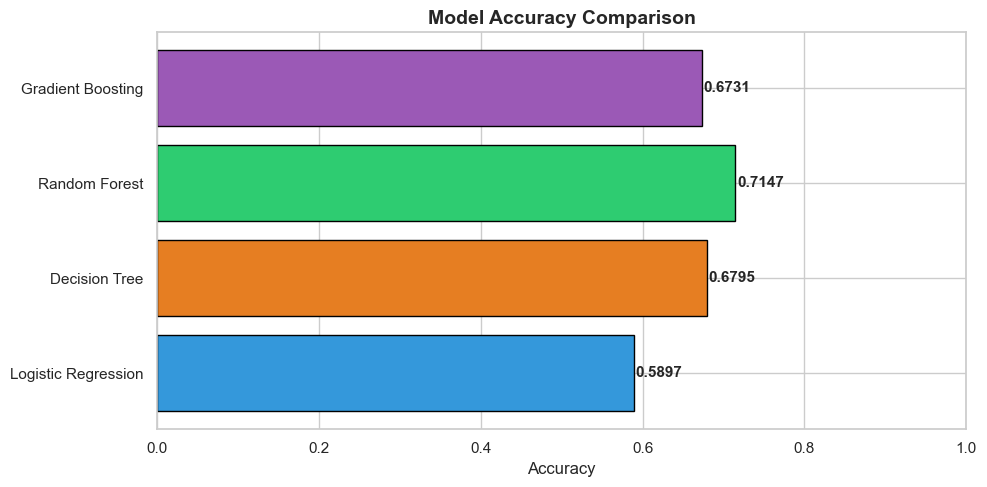

In [29]:
# Model accuracy comparison chart
plt.figure(figsize=(10, 5))
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']
bars = plt.barh(list(results.keys()), list(results.values()), color=colors, edgecolor='black')
for bar, val in zip(bars, results.values()):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontweight='bold')
plt.xlim(0, 1)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Accuracy')
plt.tight_layout()
plt.show()

=== Random Forest — Classification Report ===
                   precision    recall  f1-score   support

  Low Rating (<7)       0.74      0.61      0.67       147
High Rating (>=7)       0.70      0.81      0.75       165

         accuracy                           0.71       312
        macro avg       0.72      0.71      0.71       312
     weighted avg       0.72      0.71      0.71       312



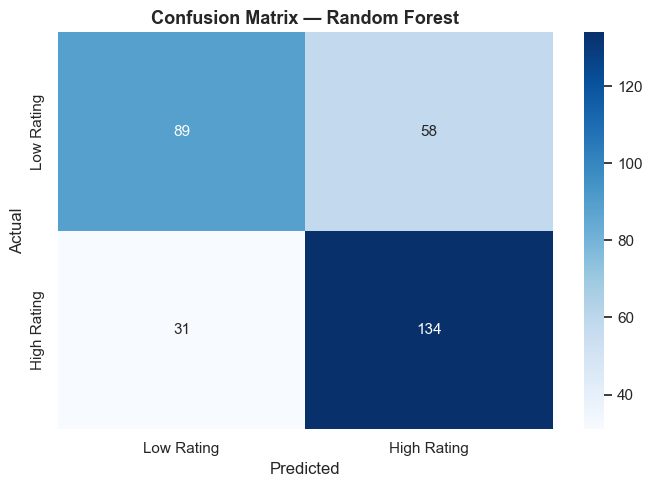

In [30]:
# Best model: Random Forest — detailed report
best_model = models['Random Forest']
y_pred_best = best_model.predict(X_test)

print('=== Random Forest — Classification Report ===')
print(classification_report(y_test, y_pred_best, target_names=['Low Rating (<7)', 'High Rating (>=7)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Rating', 'High Rating'],
            yticklabels=['Low Rating', 'High Rating'])
plt.title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

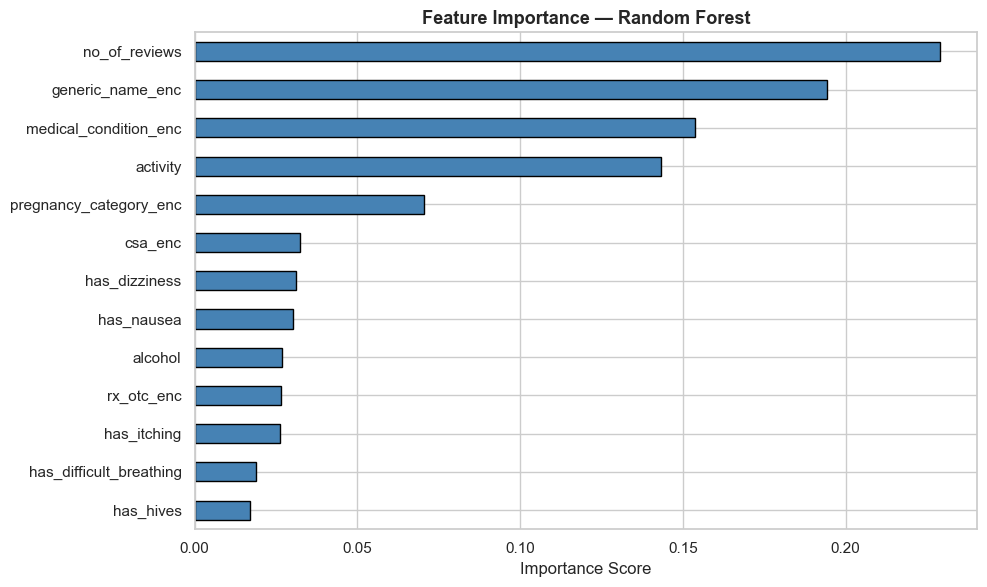

In [31]:
# Feature Importance from Random Forest
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
## 🔵 Section 8: Clustering — K-Means Drug Grouping

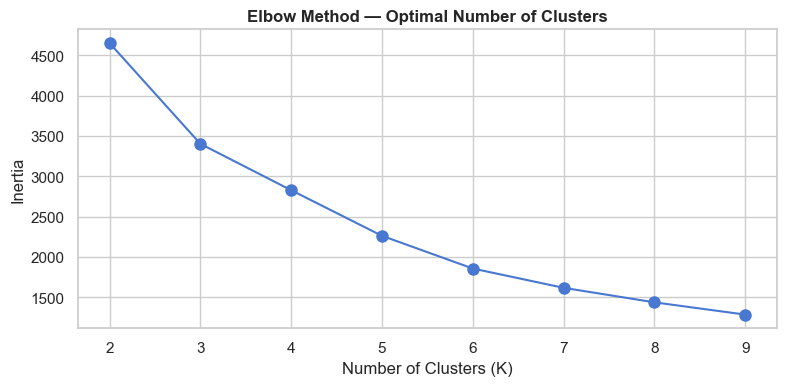

In [32]:
# Prepare data for clustering (use drugs with ratings)
cluster_data = ml_data[['activity', 'rating', 'no_of_reviews', 'alcohol']].copy()
cluster_scaled = StandardScaler().fit_transform(cluster_data)

# Elbow Method to find optimal K
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', markersize=8)
plt.title('Elbow Method — Optimal Number of Clusters', fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

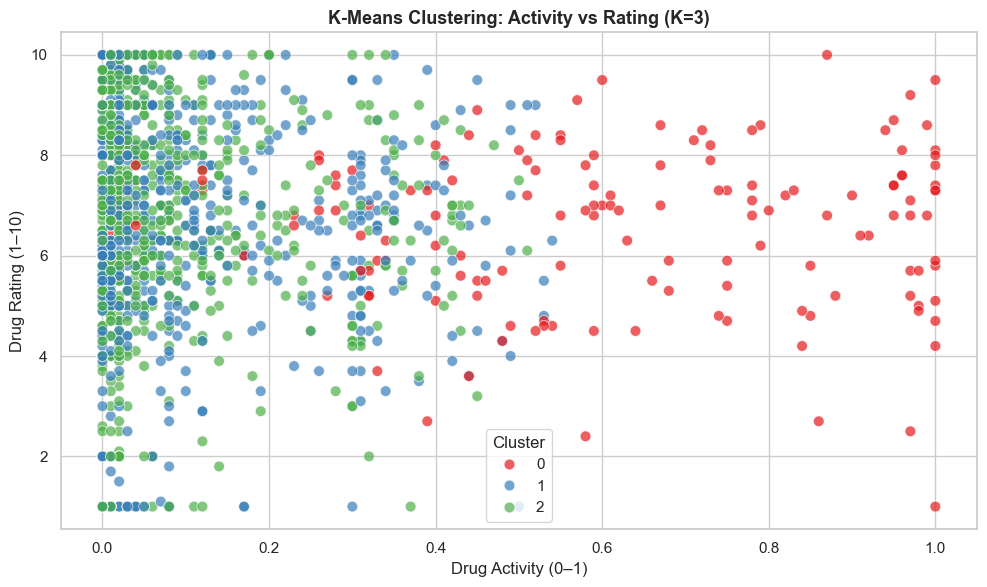

=== Cluster Summary ===
         activity  rating  no_of_reviews
cluster                                 
0            0.63    6.57         414.93
1            0.10    6.94          37.29
2            0.08    6.99          45.85


In [33]:
# Fit with K=3
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
ml_data = ml_data.copy()
ml_data['cluster'] = km_final.fit_predict(cluster_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=ml_data, x='activity', y='rating',
    hue='cluster', palette='Set1', alpha=0.7, s=60
)
plt.title('K-Means Clustering: Activity vs Rating (K=3)', fontsize=13, fontweight='bold')
plt.xlabel('Drug Activity (0–1)')
plt.ylabel('Drug Rating (1–10)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# Cluster summary
print('=== Cluster Summary ===')
print(ml_data.groupby('cluster')[['activity', 'rating', 'no_of_reviews']].mean().round(2))

---
## 📈 Section 9: Top Drugs per Condition Analysis

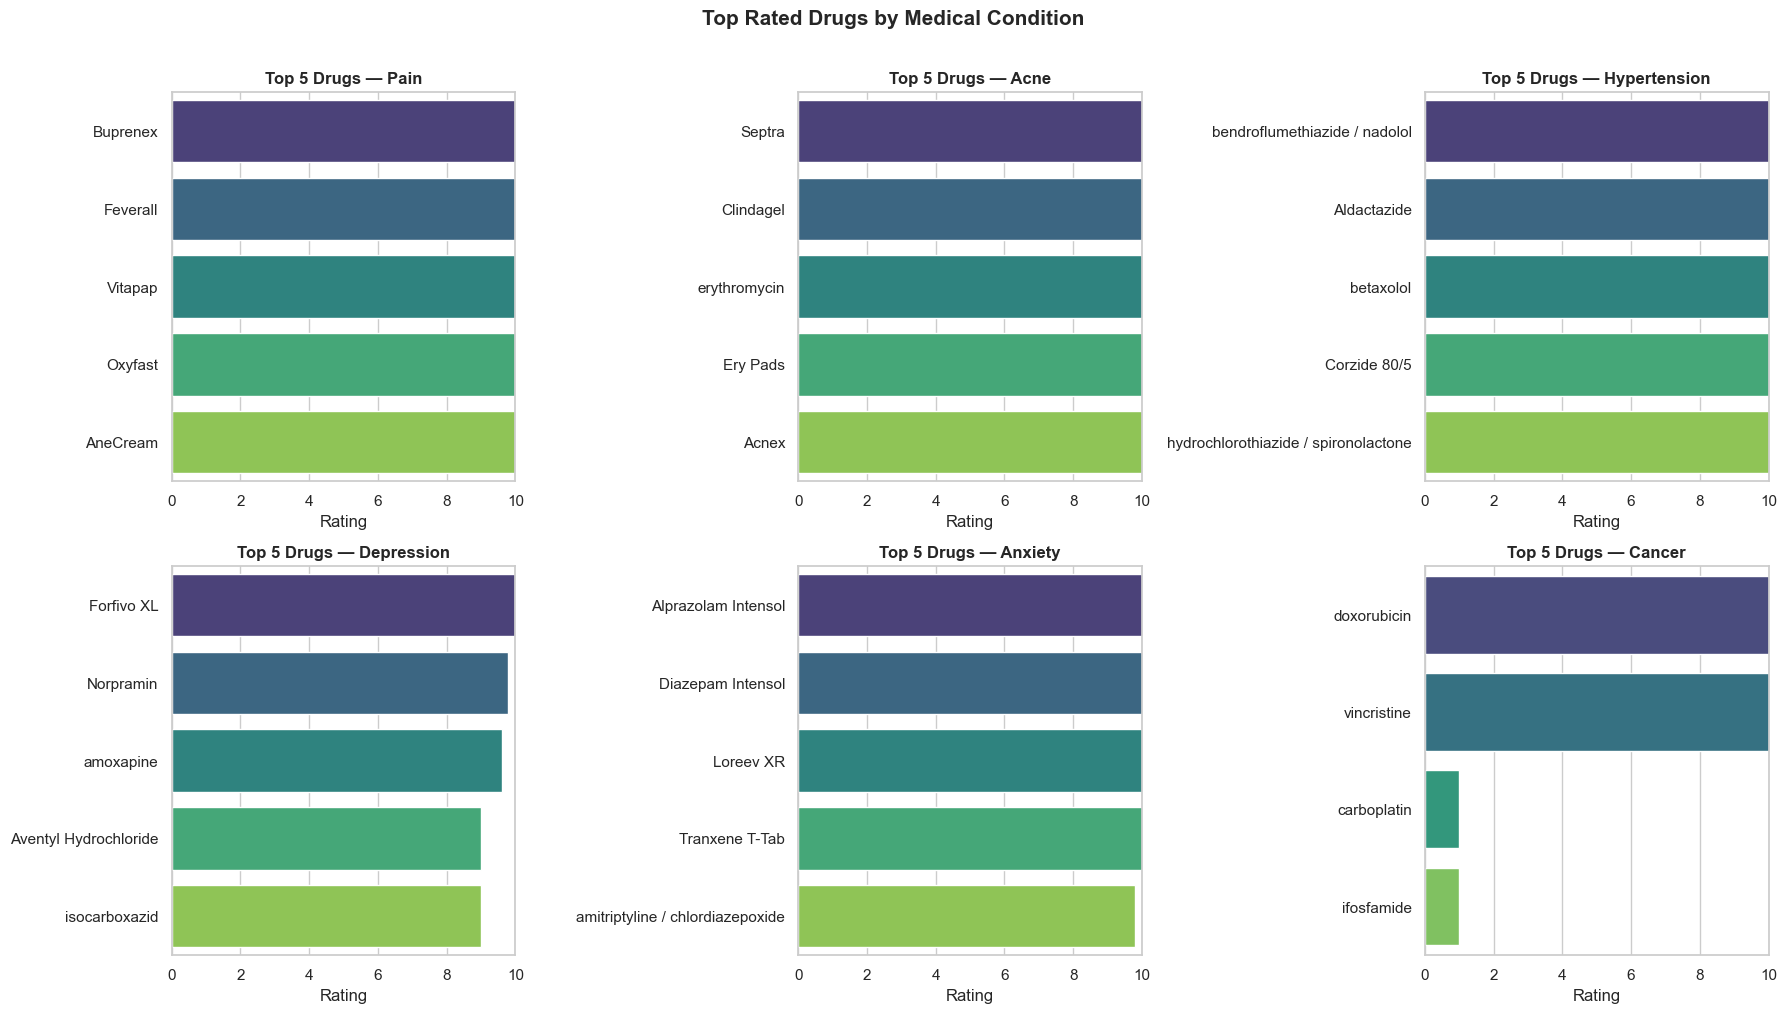

In [34]:
# Top 5 highest rated drugs for selected conditions
conditions_of_interest = ['Pain', 'Acne', 'Hypertension', 'Depression', 'Anxiety', 'Cancer']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, condition in enumerate(conditions_of_interest):
    top = (
        data[(data['medical_condition'] == condition) & (data['rating'] > 0)]
        .nlargest(5, 'rating')[['drug_name', 'rating']]
    )
    sns.barplot(data=top, x='rating', y='drug_name',
                palette='viridis', ax=axes[i])
    axes[i].set_title(f'Top 5 Drugs — {condition}', fontweight='bold')
    axes[i].set_xlabel('Rating')
    axes[i].set_ylabel('')
    axes[i].set_xlim(0, 10)

plt.suptitle('Top Rated Drugs by Medical Condition', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## ✅ Section 10: Conclusions & Key Insights

### 📌 Key Findings

| # | Insight |
|---|--------|
| 1 | **Pain, Colds & Flu, and Acne** have the most drugs available (highest drug counts per condition). |
| 2 | Drug ratings are generally **right-skewed**, with most drugs rated between 6–8 out of 10. |
| 3 | **Prescription drugs (Rx)** dominate the dataset (~75%), with OTC and Rx/OTC drugs being less common. |
| 4 | **Hives and difficult breathing** are the most commonly reported side effects across all drugs. |
| 5 | **Pregnancy category C and D** drugs are most prevalent — many drugs carry moderate to high fetal risk. |
| 6 | The **Random Forest model** achieved the best accuracy in predicting high-rated drugs. |
| 7 | **Number of reviews and activity level** are the most important features for predicting drug rating. |
| 8 | **K-Means clustering** identified 3 distinct drug groups based on activity, rating, and reviews. |
| 9 | Drugs with alcohol interactions show slightly **different rating distributions** compared to non-interacting drugs. |
| 10 | Upper respiratory combinations and topical acne agents are the **most frequent drug classes** in the dataset. |

---

### 🚀 Next Steps
- Apply **NLP / TF-IDF** on the `side_effects` column for richer text analysis.
- Build a **drug recommendation system** based on condition and safety profile.
- Use **association rule mining** (Apriori) to find co-occurring side effects.
- Deploy insights via a **Flask dashboard** or **Streamlit app**.